<a href="https://colab.research.google.com/github/MavrinIlua/Mavrin-Ilua-Borisovich_ResumeAndPortfolio/blob/main/%D0%9C%D0%B0%D0%B2%D1%80%D0%B8%D0%BD_%D0%98%D0%BB%D1%8C%D1%8F_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%BD%D0%B5%D0%BB%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D1%8B%D1%85_%D1%83%D1%80%D0%B0%D0%B2%D0%BD%D0%B5%D0%BD%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Прикладная вычислительная математика. Лабораторная 2.**

## Маврин Илья Борисович. Магистратура. Группа ППК-251м.
## Общее заключение по лабораторной работе 2

Исследование численных методов показало, что каждый из них имеет свои плюсы и минусы. Метод Ньютона быстр, но требует производной и хорошего начального приближения. Бисекция гарантированно сходится, хотя и медленно. Метод секущих является компромиссом, не требующим производной и предлагающим среднюю скорость сходимости. Выбор метода зависит от свойств функции, требований к точности и скорости вычислений.

## 1. Начальное тестирование методов на одной функции

Здесь мы начинаем с определения целевой функции $f(x) = \tan(x) - x^2 - 1$ и её производной. Применяем методы бисекции, Ньютона и секущих для нахождения корня. Сравниваем количество итераций, необходимых для сходимости, и представляем результаты в таблице `pandas`.


In [ ]:
import numpy as np
from scipy import optimize
import pandas as pd

def f(x):
    return np.tan(x) - x**2 - 1

def df(x):
    return 1/np.cos(x)**2 - 2*x

# Метод бисекции
root_bis, info_bis = optimize.bisect(f, 1.0, 1.5, xtol=1e-6, full_output=True)
it_bis = info_bis.iterations

# Метод Ньютона с производной
root_newt, info_newt = optimize.newton(f, 1.2, fprime=df, tol=1e-6,
                                       full_output=True, maxiter=100)
it_newt = info_newt.iterations

# Метод секущих (newton без производной)
root_sec, info_sec = optimize.newton(f, 1.0, x1=1.5, tol=1e-6,
                                     full_output=True, maxiter=100)
it_sec = info_sec.iterations

# Результаты в таблицу
results = pd.DataFrame({
    'Метод': ['Бисекция', 'Ньютон', 'Секущих'],
    'Корень': [root_bis, root_newt, root_sec],
    'Итерации': [it_bis, it_newt, it_sec],
    'f(корень)': [f(root_bis), f(root_newt), f(root_sec)]
})

print("Решение tan(x) - x² - 1 = 0:")
print(results.round(8))

Решение tan(x) - x² - 1 = 0:
      Метод    Корень  Итерации     f(корень)
0  Бисекция  1.172093        19 -9.700000e-07
1    Ньютон  1.172094         4  0.000000e+00
2   Секущих  1.172094         9  0.000000e+00


## 2. Визуализация процесса сходимости метода Ньютона (первичная)

Эта ячейка визуализирует работу метода Ньютона на функции $f(x) = \tan(x) - x^2 - 1$. Мы отслеживаем и графически показываем, как каждое следующее приближение $x_{k+1}$ находится через касательную к функции. Это помогает наглядно продемонстрировать итерационный процесс сходимости к корню.

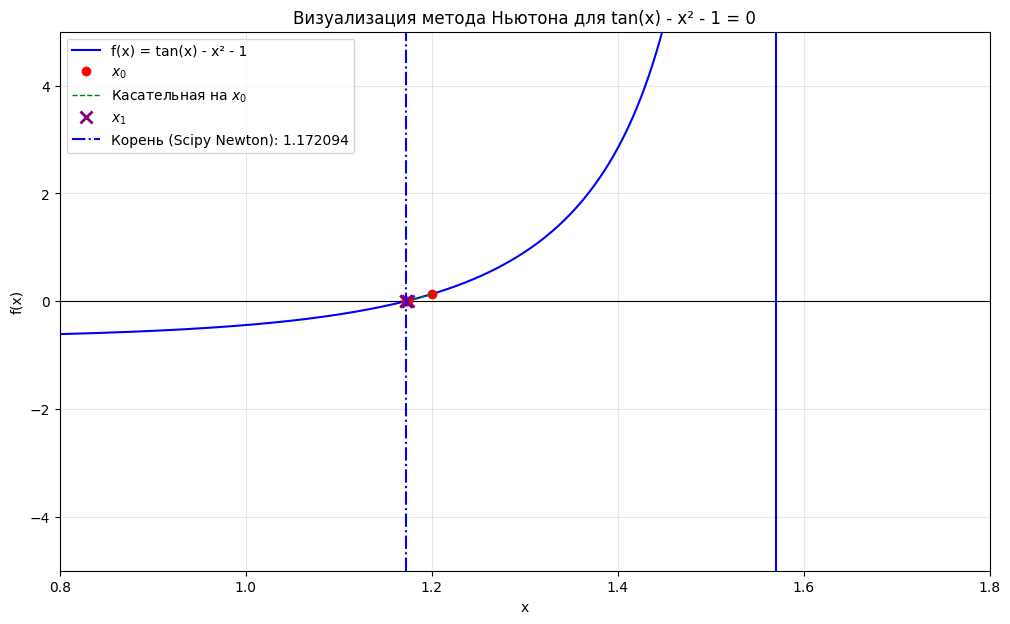

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def newton_method_visualization(f, df, x0, tol=1e-6, maxiter=100):
    x_history = [x0]
    for i in range(maxiter):
        fx = f(x0)
        dfx = df(x0)
        if abs(dfx) < 1e-10: # Avoid division by zero if derivative is too small
            print(f"Warning: Derivative very close to zero at x = {x0}. Stopping.")
            break
        x_new = x0 - fx / dfx
        x_history.append(x_new)
        if abs(x_new - x0) < tol:
            break
        x0 = x_new
    return x_history

# Initial guess for Newton's method
x_initial = 1.2

# Get the steps for visualization
x_steps = newton_method_visualization(f, df, x_initial, tol=1e-6, maxiter=100)

# Create the plot
plt.figure(figsize=(12, 7))
x_plot_range = np.linspace(0.8, 1.8, 500) # Ensure it covers the relevant range
plt.plot(x_plot_range, f(x_plot_range), 'b-', label='f(x) = tan(x) - x² - 1')
plt.axhline(0, color='k', lw=0.8)

# Plot the tangent lines and iteration steps
for i in range(len(x_steps) - 1):
    x_k = x_steps[i]
    x_k_plus_1 = x_steps[i+1]
    y_k = f(x_k)
    df_k = df(x_k)

    # Plot the point on the curve
    plt.plot(x_k, y_k, 'o', color='red', markersize=6, label=f'$x_{i}$' if i == 0 else "")

    # Plot the tangent line from (x_k, f(x_k)) to (x_{k+1}, 0)
    # The tangent line equation is y - y_k = df_k * (x - x_k)
    # For plotting, we need two points: (x_k, y_k) and (x_{k+1}, 0)
    tangent_x_points = np.array([x_k, x_k_plus_1])
    tangent_y_points = f(x_k) + df_k * (tangent_x_points - x_k)
    plt.plot(tangent_x_points, tangent_y_points, 'g--', linewidth=1.0, label=f'Касательная на $x_{i}$' if i == 0 else "")

    # Indicate the next x-intercept (x_k+1)
    plt.plot(x_k_plus_1, 0, 'x', color='purple', markersize=8, markeredgewidth=2, label=f'$x_{i+1}$' if i == 0 else "")


# Mark the final root found by scipy's newton method for comparison
plt.axvline(root_newt, color='blue', linestyle='-.', label=f'Корень (Scipy Newton): {root_newt:.6f}')


plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Визуализация метода Ньютона для tan(x) - x² - 1 = 0')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-5, 5) # Set a reasonable y-limit for better visualization of tangents
plt.xlim(0.8, 1.8) # Adjust x-limits to focus on convergence
plt.show()

## 3. Расширенный анализ: сравнение методов на разных функциях

Для оценки универсальности методов, в этой ячейке мы тестируем их на четырех различных функциях, включая функции с особенностями. Используется улучшенный подход для бисекции с автоматическим поиском интервала. Анализируем количество итераций для каждого метода на разных функциях, чтобы понять влияние их характеристик на сходимость.
```

In [ ]:
from scipy import optimize
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Определяем функции
def f1(x): return x**3 - x - 2
def f2(x): return x * np.sin(1/x)
def f3(x): return (x - 1)**3
def f4(x): return np.tan(x) - x

# Производные для метода Ньютона
def f1_prime(x): return 3*x**2 - 1
def f3_prime(x): return 3*(x - 1)**2

# Начальные приближения
x0_list = [1.5, 0.5, 1.1, 4.5]  # для f4 — 4.5

# Функция для поиска интервала с разными знаками
def find_bracket(f, x0, step=0.1, max_steps=100):
    a, b = x0, x0
    fa, fb = f(a), f(b)
    for _ in range(max_steps):
        if fa * fb < 0:
            return a, b
        a -= step
        b += step
        fa, fb = f(a), f(b)
    raise ValueError(f"Не удалось найти интервал с разными знаками для функции")

# Словари для хранения результатов
roots = {'bisect': [], 'newton': [], 'secant': []}
iterations = {'newton': [], 'secant': []}

# Список функций (уберите f4, если нужно только 3)
functions = [f1, f2, f3, f4]
function_names = ['f1', 'f2', 'f3', 'f4']

for i, f in enumerate(functions):
    x0 = x0_list[i]
    func_name = function_names[i]

    print(f"\n=== Функция {func_name} ===")

    # 1. Метод дихотомии
    try:
        a, b = find_bracket(f, x0)
        print(f"Интервал для bisect: [{a:.3f}, {b:.3f}]")
        root_bisect = optimize.bisect(f, a, b)
        roots['bisect'].append(root_bisect)
        print(f"Корень (bisect): {root_bisect:.6f}")
    except Exception as e:
        print(f"Ошибка для bisect: {e}")
        roots['bisect'].append(np.nan)
        continue

    # 2. Метод Ньютона
    try:
        if i == 0:
            root_newton, result_newton = optimize.newton(
                f, x0, fprime=f1_prime, full_output=True, maxiter=100
            )
        elif i == 2:
            root_newton, result_newton = optimize.newton(
                f, x0, fprime=f3_prime, full_output=True, maxiter=100
            )
        else:
            root_newton, result_newton = optimize.newton(
                f, x0, full_output=True, maxiter=100
            )
        roots['newton'].append(root_newton)
        iterations['newton'].append(result_newton.iterations)
        print(f"Корень (Newton): {root_newton:.6f}, итераций: {result_newton.iterations}")
    except RuntimeError as e:
        print(f"Ньютон не сошёлся: {e}")
        roots['newton'].append(np.nan)
        iterations['newton'].append(np.nan)

    # 3. Метод секущих
    try:
        root_secant, result_secant = optimize.newton(
            f, x0, fprime=None, full_output=True, disp=False, maxiter=100
        )
        roots['secant'].append(root_secant)
        iterations['secant'].append(result_secant.iterations)
        print(f"Корень (secant): {root_secant:.6f}, итераций: {result_secant.iterations}")
    except RuntimeError as e:
        print(f"Секущие не сошлись: {e}")
        roots['secant'].append(np.nan)
        iterations['secant'].append(np.nan)

# Продолжение кода: построение графиков, таблица результатов, выводы — без изменений



=== Функция f1 ===
Интервал для bisect: [1.400, 1.600]
Корень (bisect): 1.521380
Корень (Newton): 1.521380, итераций: 4
Корень (secant): 1.521380, итераций: 4

=== Функция f2 ===
Интервал для bisect: [0.300, 0.700]
Корень (bisect): 0.318310
Корень (Newton): 0.318310, итераций: 6
Корень (secant): 0.318310, итераций: 6

=== Функция f3 ===
Интервал для bisect: [0.900, 1.300]
Корень (bisect): 1.000000
Корень (Newton): 1.000000, итераций: 38
Корень (secant): 1.000000, итераций: 52

=== Функция f4 ===
Интервал для bisect: [4.400, 4.600]
Корень (bisect): 4.493409
Корень (Newton): 4.493409, итераций: 4
Корень (secant): 4.493409, итераций: 4


## 4. Детальная визуализация метода Ньютона: первые итерации для $f(x) = \tan(x) - x^2 - 1$

Здесь представлена детальная визуализация первых трех итераций метода Ньютона для $f(x) = \tan(x) - x^2 - 1$. Мы намеренно отодвинули начальное приближение, чтобы шаги были хорошо видны. График наглядно демонстрирует, как касательные ведут к корню, а аннотации показывают каждый шаг алгоритма.

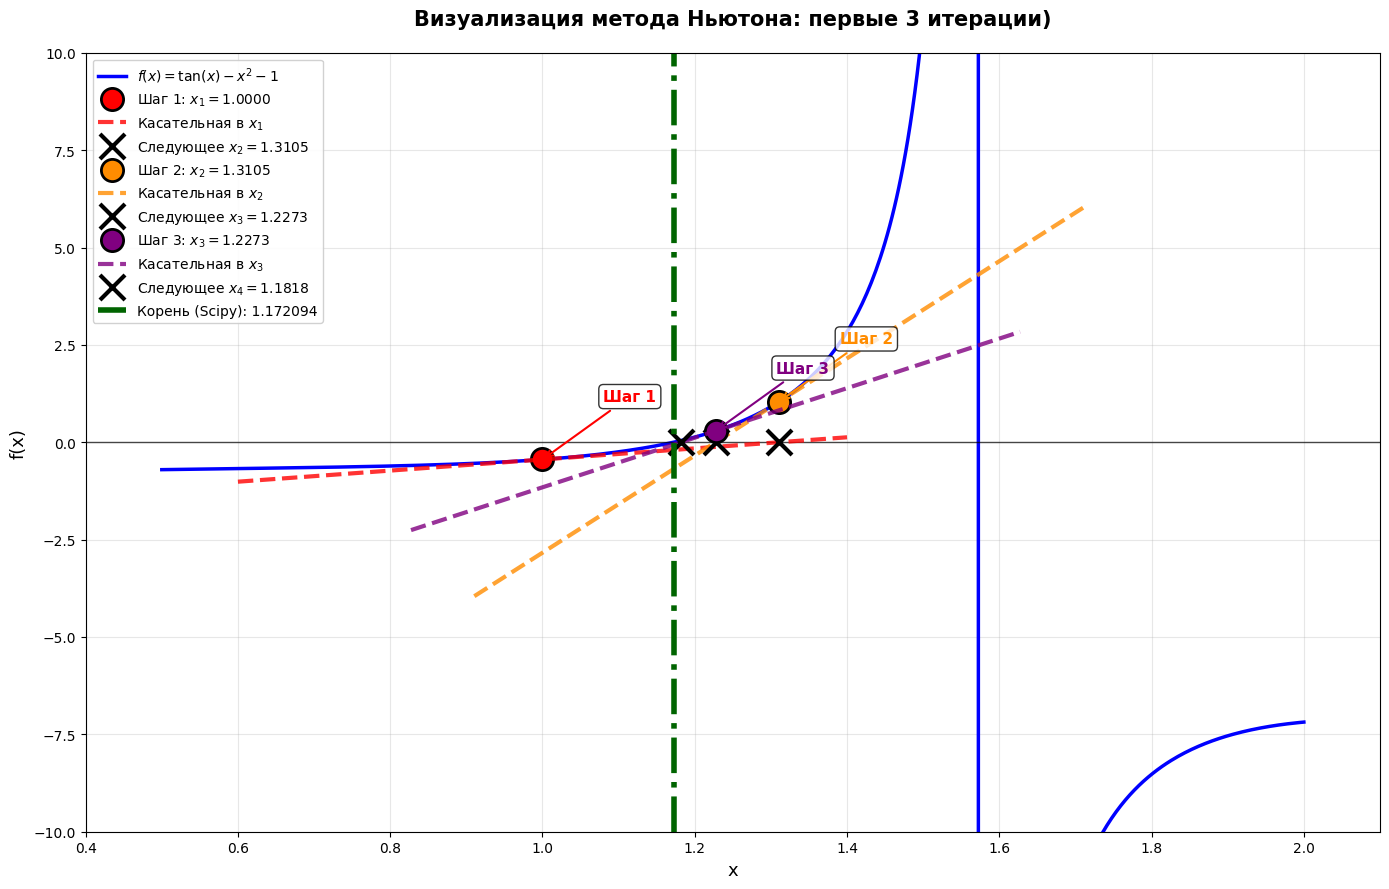

Результаты первых 3 итераций метода Ньютона:
---------------------------------------------
Шаг 0: x = 1.000000, f(x) = -0.442592
Шаг 1: x = 1.310478, f(x) = 1.036931
Шаг 2: x = 1.227349, f(x) = 0.289873
Шаг 3: x = 1.181802, f(x) = 0.043085

Всего выполнено итераций: 3


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize

# Определяем функцию и её производную
def f(x):
    return np.tan(x) - x**2 - 1

def df(x):
    return 1 / np.cos(x)**2 - 2 * x

def newton_visual(f, df, x0, tol=1e-6, maxiter=100):
    history = [x0]
    for _ in range(maxiter):
        fx, dfx = f(x0), df(x0)
        if abs(dfx) < 1e-10:
            print("Предупреждение: производная близка к нулю. Остановка.")
            break
        x_new = x0 - fx / dfx
        history.append(x_new)
        if abs(x_new - x0) < tol:
            break
        x0 = x_new
    return history

# Параметры
x0 = 1.0  # Сдвигаем начальное приближение для лучшего распределения шагов
x_range = np.linspace(0.5, 2.0, 500)  # Расширяем диапазон для лучшей видимости

# Вычисляем шаги метода Ньютона
steps = newton_visual(f, df, x0)

# Берём только первые 3 шага (4 точки: начальная + 3 итерации)
steps_limited = steps[:4]

# Строим график
plt.figure(figsize=(14, 9))
plt.plot(x_range, f(x_range), 'b-', label='$f(x) = \\tan(x) - x^2 - 1$', linewidth=2.5)
plt.axhline(0, color='k', linewidth=1.0, alpha=0.7)

colors = ['red', 'darkorange', 'purple']  # Яркие цвета для лучшей различимости

# Отмечаем шаги метода (только первые 3 итерации)
for i in range(len(steps_limited) - 1):
    x_curr, x_next = steps_limited[i], steps_limited[i+1]
    y_curr = f(x_curr)
    df_curr = df(x_curr)

    # Расширяем касательную для лучшей видимости (строим на большем интервале)
    tangent_x_extended = np.linspace(x_curr - 0.4, x_curr + 0.4, 80)
    tangent_y_extended = y_curr + df_curr * (tangent_x_extended - x_curr)

    # Точка на кривой — крупная и заметная
    plt.plot(x_curr, y_curr, 'o', color=colors[i], markersize=16,
              markeredgewidth=2, markeredgecolor='black',
              label=f'Шаг {i+1}: $x_{i+1} = {x_curr:.4f}$')

    # Касательная линия — длинная и жирная
    plt.plot(tangent_x_extended, tangent_y_extended, '--',
              color=colors[i], linewidth=3.0, alpha=0.8,
              label=f'Касательная в $x_{i+1}$')

    # Следующее приближение на оси X — крупный крестик
    plt.plot(x_next, 0, 'x', color=colors[i], markersize=18,
              markeredgewidth=3, markeredgecolor='black',
              label=f'Следующее $x_{i+2} = {x_next:.4f}$')

    # Добавляем подписи с номерами шагов рядом с точками
    plt.annotate(f'Шаг {i+1}', xy=(x_curr, y_curr),
                xytext=(x_curr + 0.08, y_curr + 1.5),
                fontsize=11, color=colors[i], fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=1.5),
                bbox=dict(boxstyle="round, pad=0.3", facecolor='white', alpha=0.8))

# Корень от scipy — жирная линия для лучшей видимости
try:
    root_scipy = optimize.newton(f, x0)
    plt.axvline(root_scipy, color='darkgreen', linestyle='-.', linewidth=4,
               label=f'Корень (Scipy): {root_scipy:.6f}')
except RuntimeError:
    print("Scipy Newton не сошёлся.")

plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left', framealpha=0.9)
plt.title('Визуализация метода Ньютона: первые 3 итерации)',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('x', fontsize=13)
plt.ylabel('f(x)', fontsize=13)

# Расширяем пределы для лучшей видимости всех элементов
plt.ylim(-10, 10)  # Увеличиваем диапазон по Y
plt.xlim(0.4, 2.1)  # Увеличиваем диапазон по X

plt.tight_layout()
plt.show()

# Вывод информации о шагах в консоль
print("Результаты первых 3 итераций метода Ньютона:")
print("-" * 45)
for i, x in enumerate(steps_limited):
    print(f"Шаг {i}: x = {x:.6f}, f(x) = {f(x):.6f}")
print(f"\nВсего выполнено итераций: {len(steps_limited)-1}")


## 5. Визуализация метода Ньютона для другой функции: $f(x) = x^3 - 2x - 5$

Эта ячейка продолжает визуализацию метода Ньютона, но уже для функции $f(x) = x^3 - 2x - 5$. Мы используем другое начальное приближение для наглядности. Цель — показать стабильность и предсказуемость метода на более простой функции, где траектория сходимости легко прослеживается.

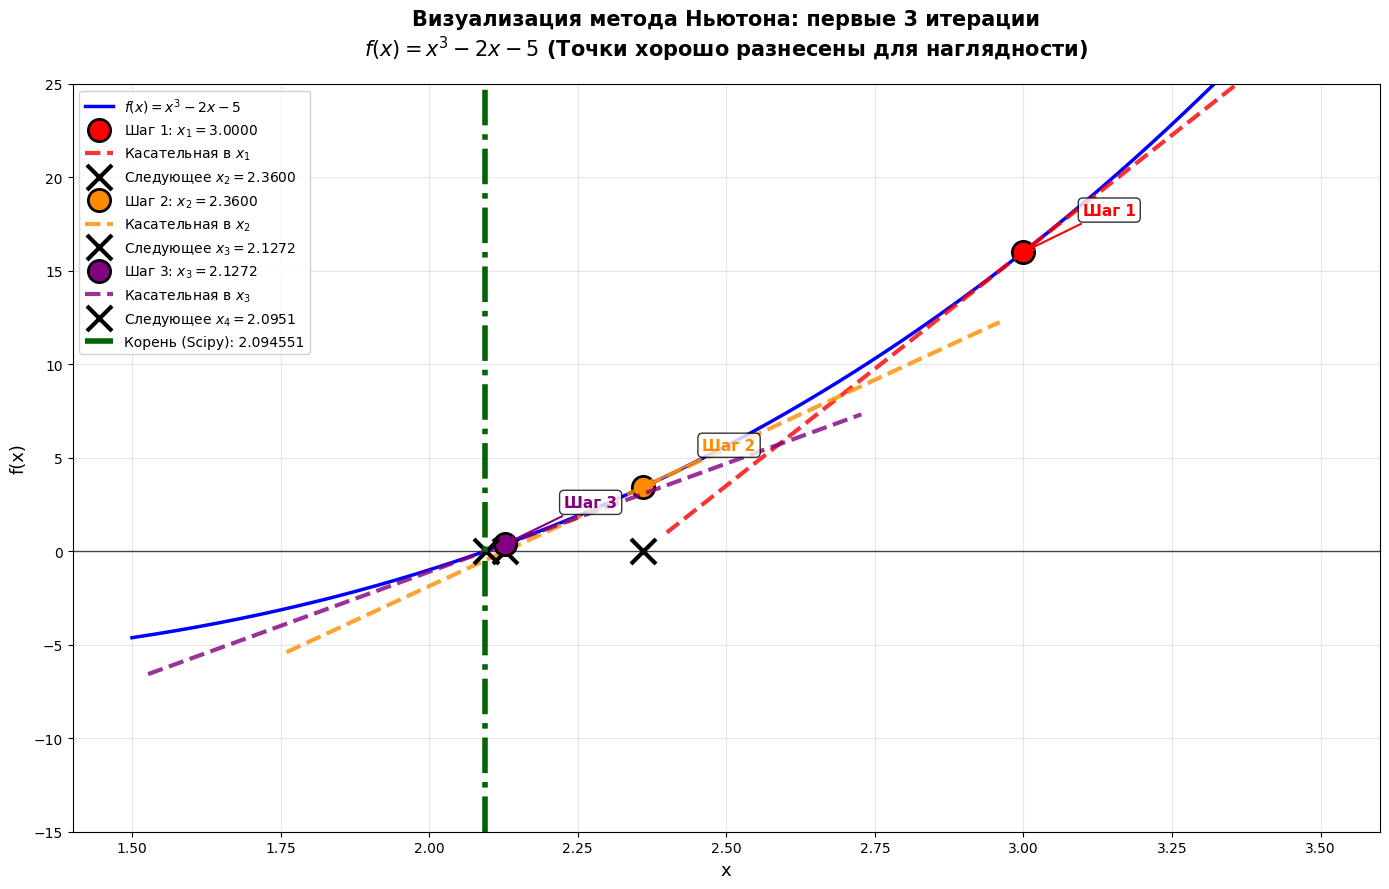

Результаты первых 3 итераций метода Ньютона:
---------------------------------------------
Шаг 0: x = 3.000000, f(x) = 16.000000
Шаг 1: x = 2.360000, f(x) = 3.424256
Шаг 2: x = 2.127197, f(x) = 0.371100
Шаг 3: x = 2.095136, f(x) = 0.006527

Всего выполнено итераций: 3
Точное решение (Scipy): 2.094551


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize

# Определяем новую функцию и её производную
def f(x):
    return x**3 - 2*x - 5

def df(x):
    return 3*x**2 - 2

def newton_visual(f, df, x0, tol=1e-6, maxiter=100):
    history = [x0]
    for _ in range(maxiter):
        fx, dfx = f(x0), df(x0)
        if abs(dfx) < 1e-10:
            print("Предупреждение: производная близка к нулю. Остановка.")
            break
        x_new = x0 - fx / dfx
        history.append(x_new)
        if abs(x_new - x0) < tol:
            break
        x0 = x_new
    return history

# Параметры для нового уравнения
x0 = 3.0  # Начальное приближение — достаточно далеко от корня для наглядности итераций
x_range = np.linspace(1.5, 3.5, 500)  # Диапазон вокруг корня

# Вычисляем шаги метода Ньютона
steps = newton_visual(f, df, x0)

# Берём только первые 3 шага (4 точки: начальная + 3 итерации)
steps_limited = steps[:4]

# Строим график
plt.figure(figsize=(14, 9))
plt.plot(x_range, f(x_range), 'b-', label='$f(x) = x^3 - 2x - 5$', linewidth=2.5)
plt.axhline(0, color='k', linewidth=1.0, alpha=0.7)

colors = ['red', 'darkorange', 'purple']  # Яркие цвета для лучшей различимости

# Отмечаем шаги метода (только первые 3 итерации)
for i in range(len(steps_limited) - 1):
    x_curr, x_next = steps_limited[i], steps_limited[i+1]
    y_curr = f(x_curr)
    df_curr = df(x_curr)

    # Расширяем касательную для лучшей видимости
    tangent_x_extended = np.linspace(x_curr - 0.6, x_curr + 0.6, 80)
    tangent_y_extended = y_curr + df_curr * (tangent_x_extended - x_curr)

    # Точка на кривой — крупная и заметная
    plt.plot(x_curr, y_curr, 'o', color=colors[i], markersize=16,
              markeredgewidth=2, markeredgecolor='black',
              label=f'Шаг {i+1}: $x_{i+1} = {x_curr:.4f}$')

    # Касательная линия — длинная и жирная
    plt.plot(tangent_x_extended, tangent_y_extended, '--',
              color=colors[i], linewidth=3.0, alpha=0.8,
              label=f'Касательная в $x_{i+1}$')

    # Следующее приближение на оси X — крупный крестик
    plt.plot(x_next, 0, 'x', color=colors[i], markersize=18,
              markeredgewidth=3, markeredgecolor='black',
              label=f'Следующее $x_{i+2} = {x_next:.4f}$')

    # Добавляем подписи с номерами шагов рядом с точками
    plt.annotate(f'Шаг {i+1}', xy=(x_curr, y_curr),
                xytext=(x_curr + 0.1, y_curr + 2),
                fontsize=11, color=colors[i], fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=1.5),
                bbox=dict(boxstyle="round, pad=0.3", facecolor='white', alpha=0.8))

# Корень от scipy — жирная линия для лучшей видимости
try:
    root_scipy = optimize.newton(f, x0)
    plt.axvline(root_scipy, color='darkgreen', linestyle='-.', linewidth=4,
               label=f'Корень (Scipy): {root_scipy:.6f}')
except RuntimeError:
    print("Scipy Newton не сошёлся.")

plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left', framealpha=0.9)
plt.title('Визуализация метода Ньютона: первые 3 итерации\n$f(x) = x^3 - 2x - 5$ (Точки хорошо разнесены для наглядности)',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('x', fontsize=13)
plt.ylabel('f(x)', fontsize=13)

# Расширяем пределы для лучшей видимости всех элементов
plt.ylim(-15, 25)  # Увеличиваем диапазон по Y
plt.xlim(1.4, 3.6)  # Увеличиваем диапазон по X

plt.tight_layout()
plt.show()

# Вывод информации о шагах в консоль
print("Результаты первых 3 итераций метода Ньютона:")
print("-" * 45)
for i, x in enumerate(steps_limited):
    print(f"Шаг {i}: x = {x:.6f}, f(x) = {f(x):.6f}")
print(f"\nВсего выполнено итераций: {len(steps_limited)-1}")
print(f"Точное решение (Scipy): {root_scipy:.6f}")


# Как в аналитике, попробуем с дашбордом

## 6. Итоговый "дашборд": комплексное сравнение всех методов на разных функциях

Данная ячейка является итоговым "дашбордом" работы, комплексно сравнивающим численные методы. Для каждой из четырех тестовых функций здесь представлены графики, демонстрирующие работу Ньютона, бисекции и секущих. Визуализация первых итераций помогает оценить скорость сходимости и особенности поведения. В конце выводится сводная таблица с количеством итераций для всех методов и функций.
```

Анализ сходимости численных методов



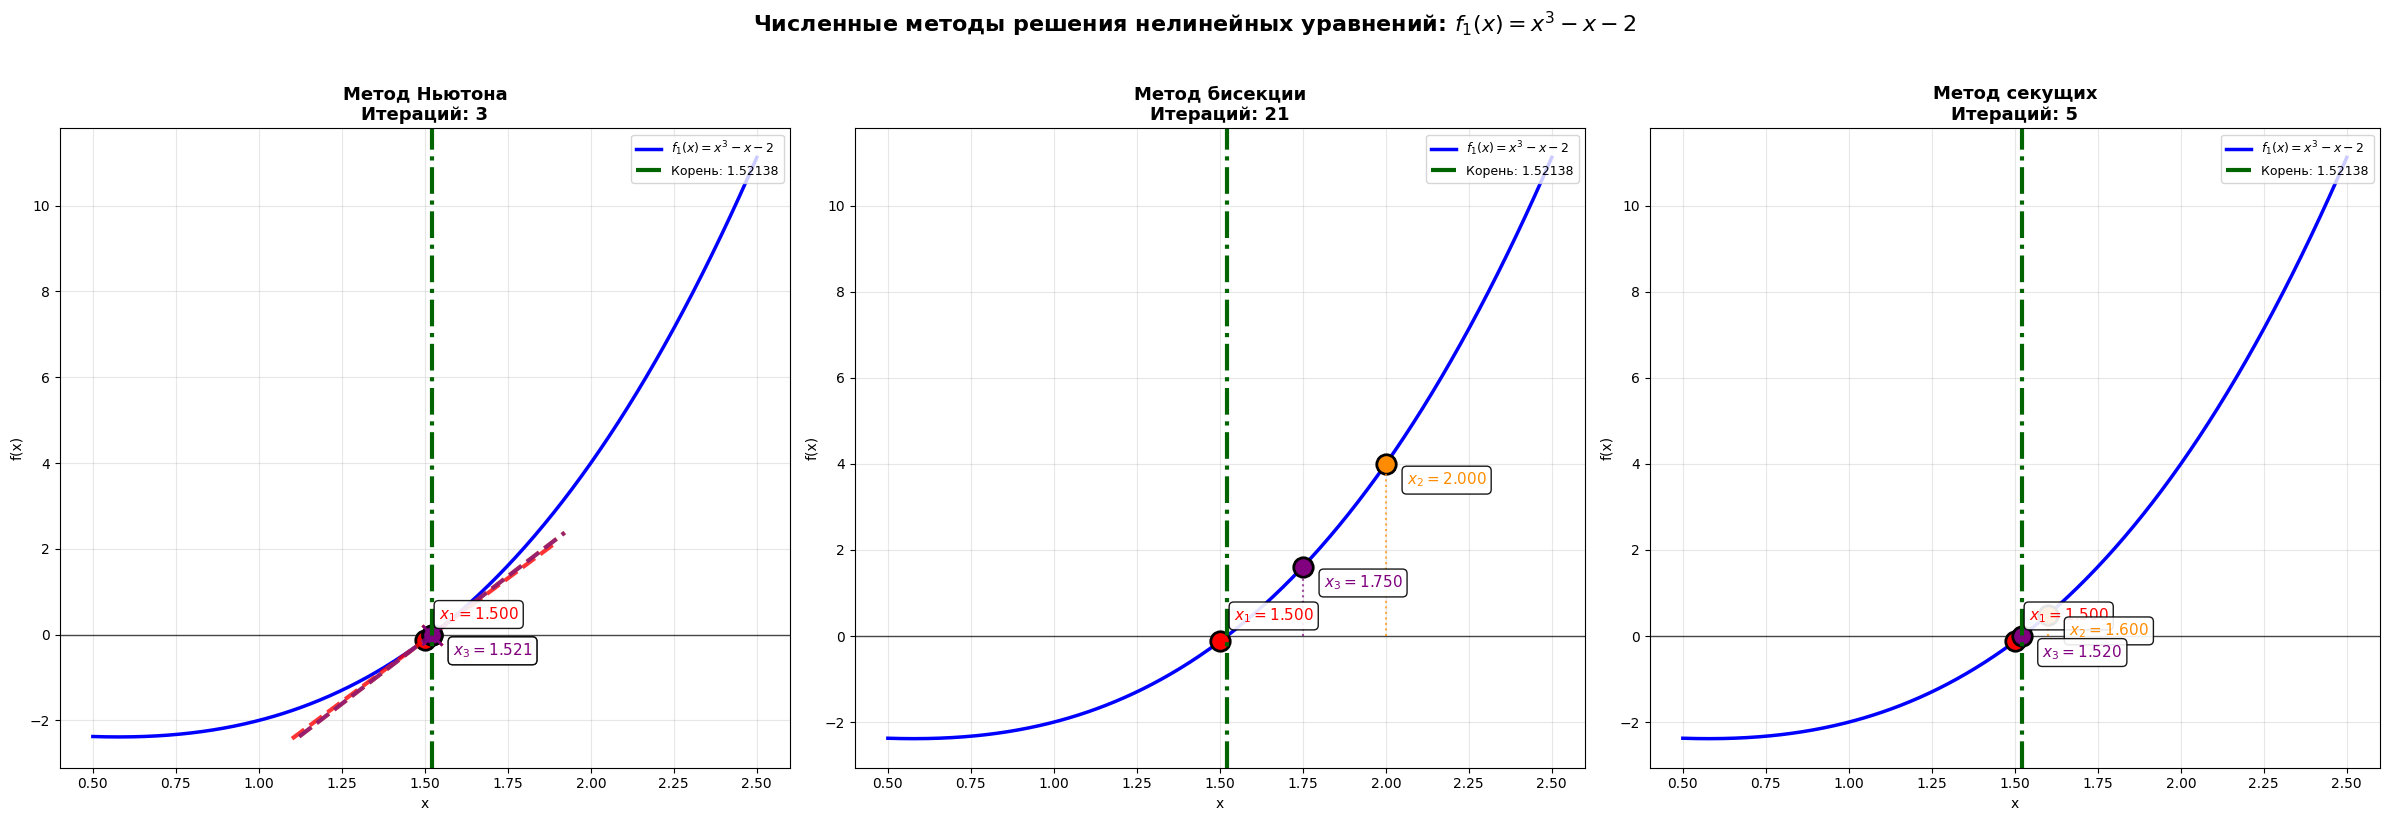

f1(x): Ньютон=3, Бисекция=21, Секущих=5


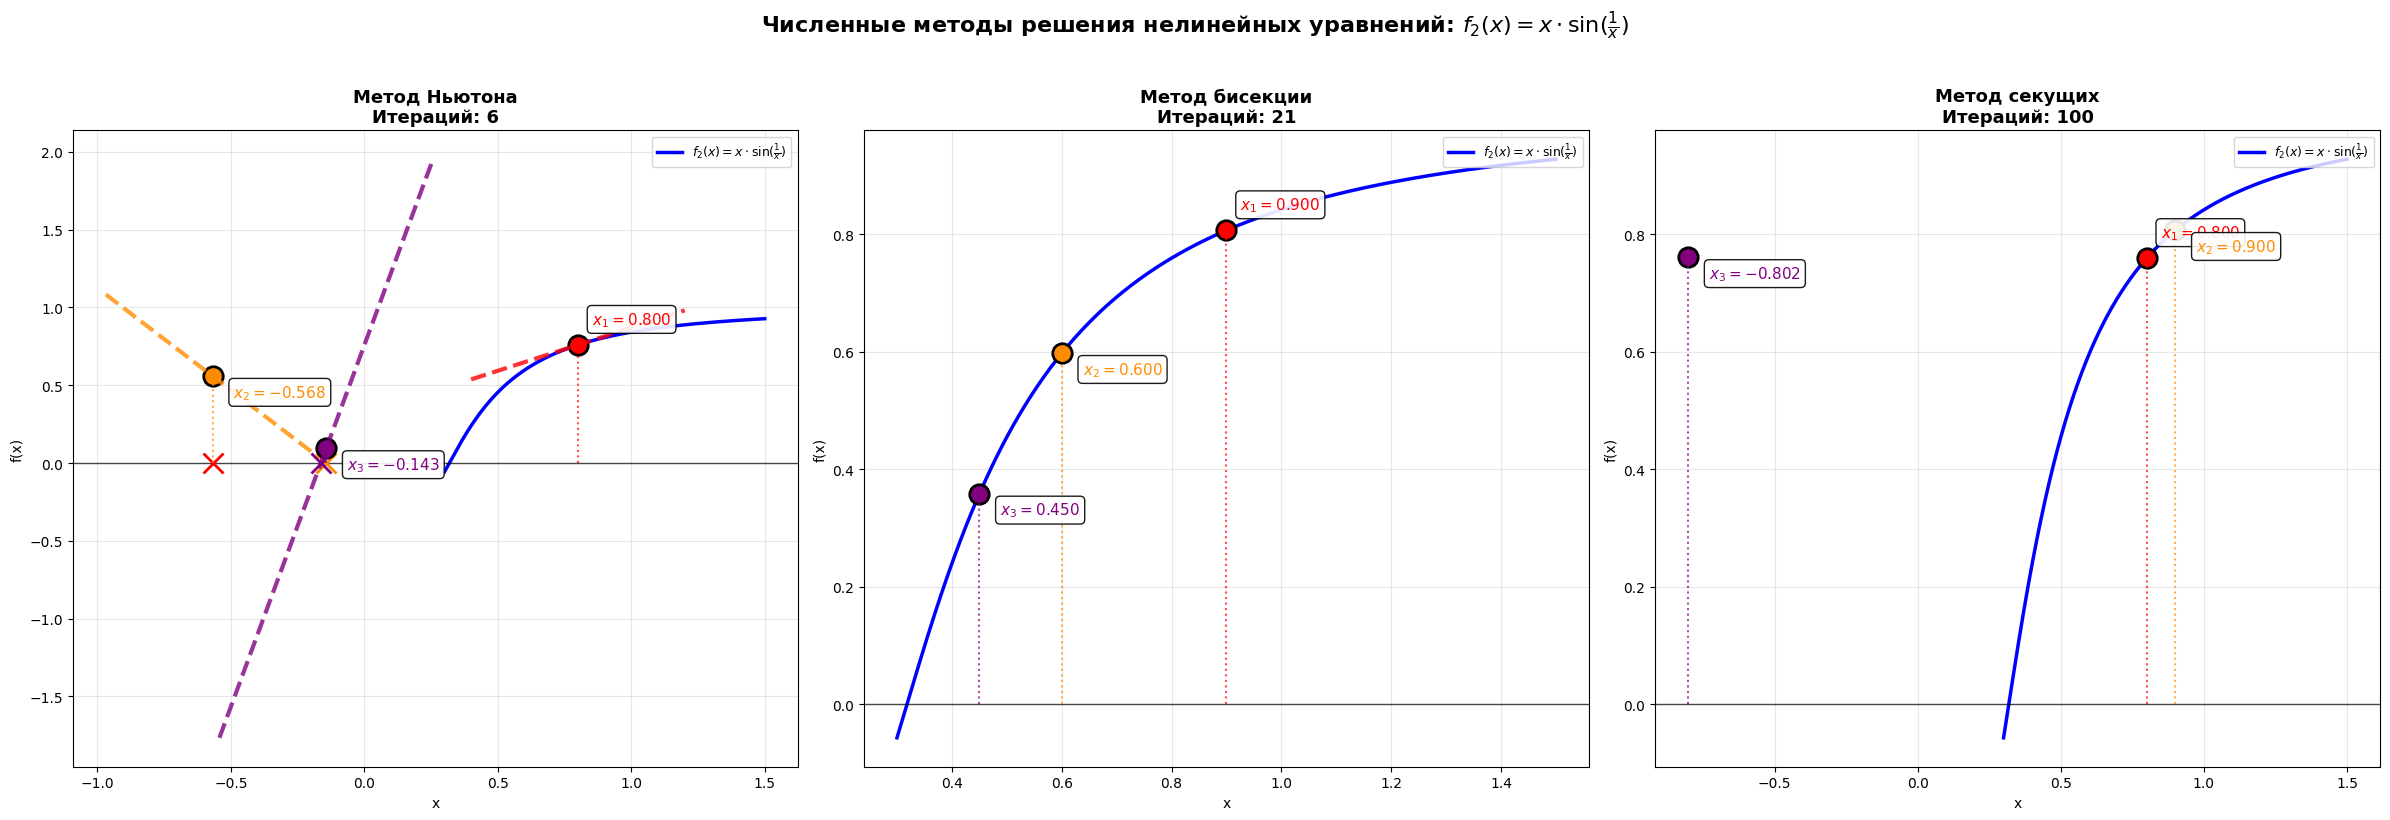

f2(x): Ньютон=6, Бисекция=21, Секущих=100


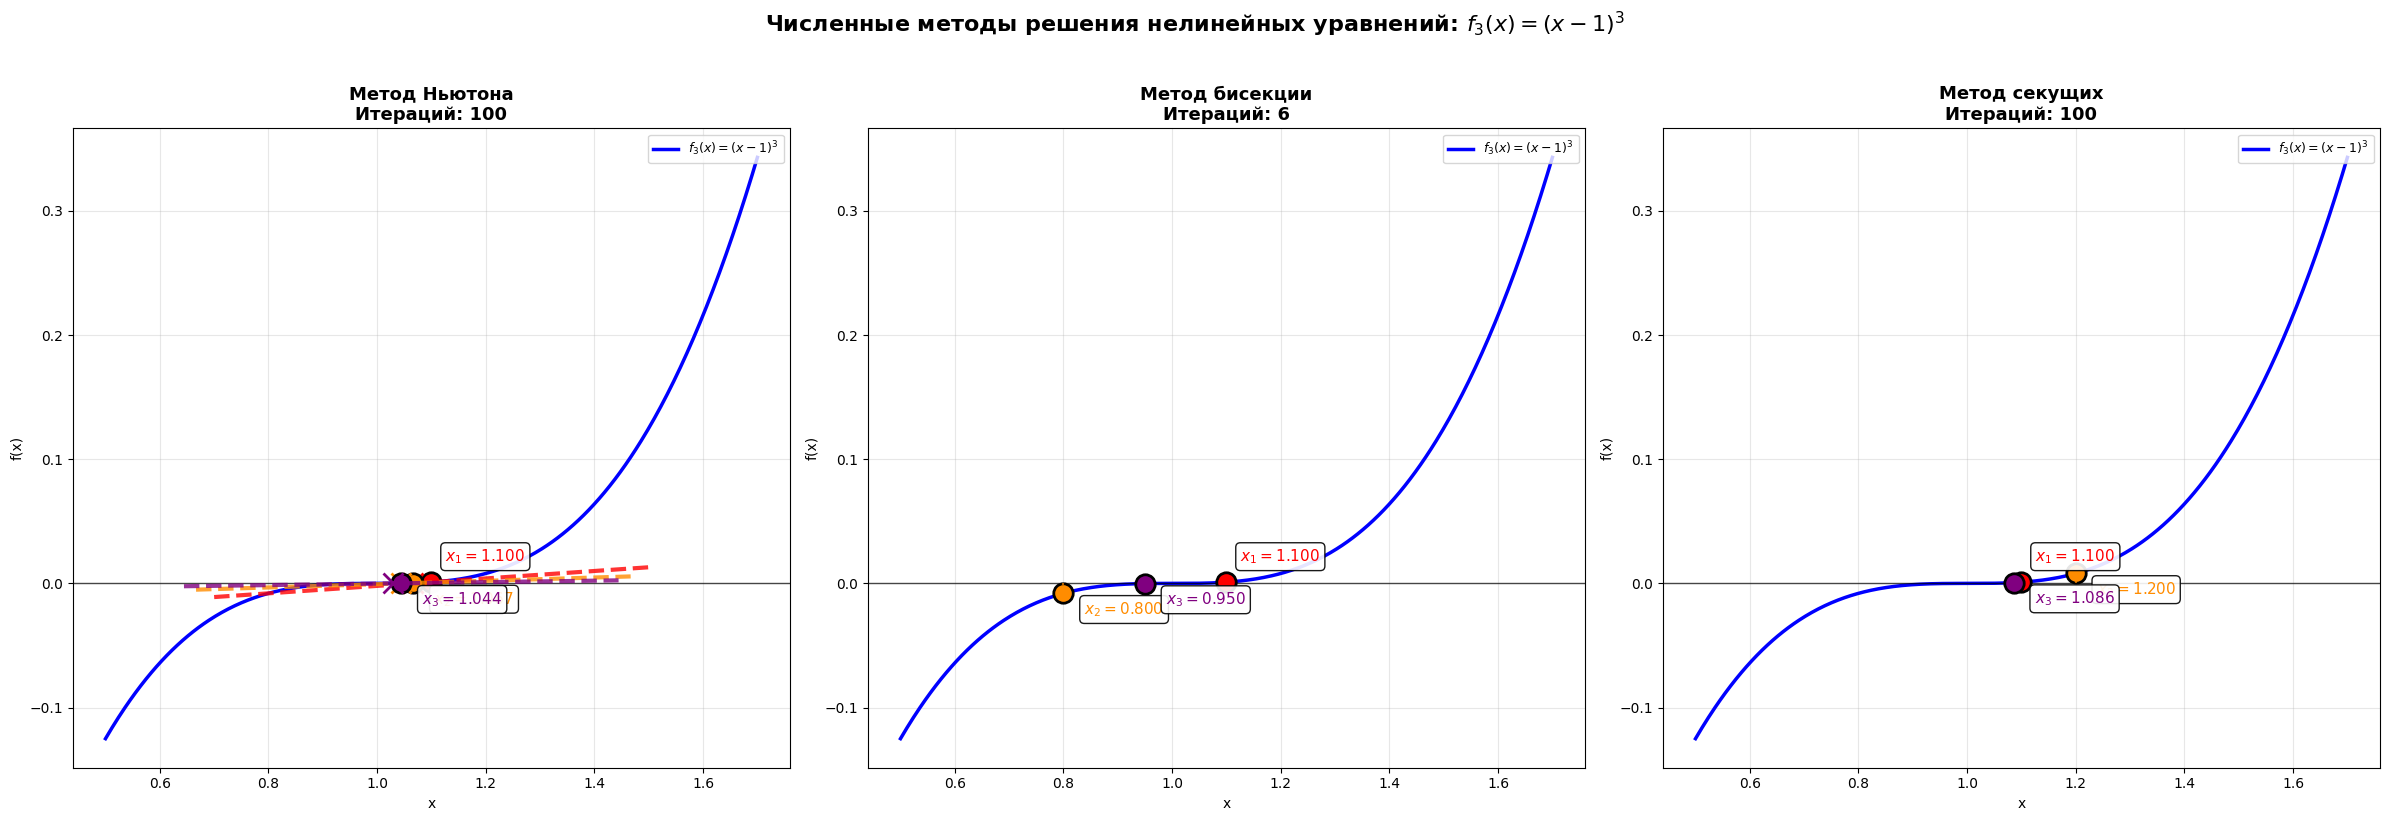

f3(x): Ньютон=100, Бисекция=6, Секущих=100


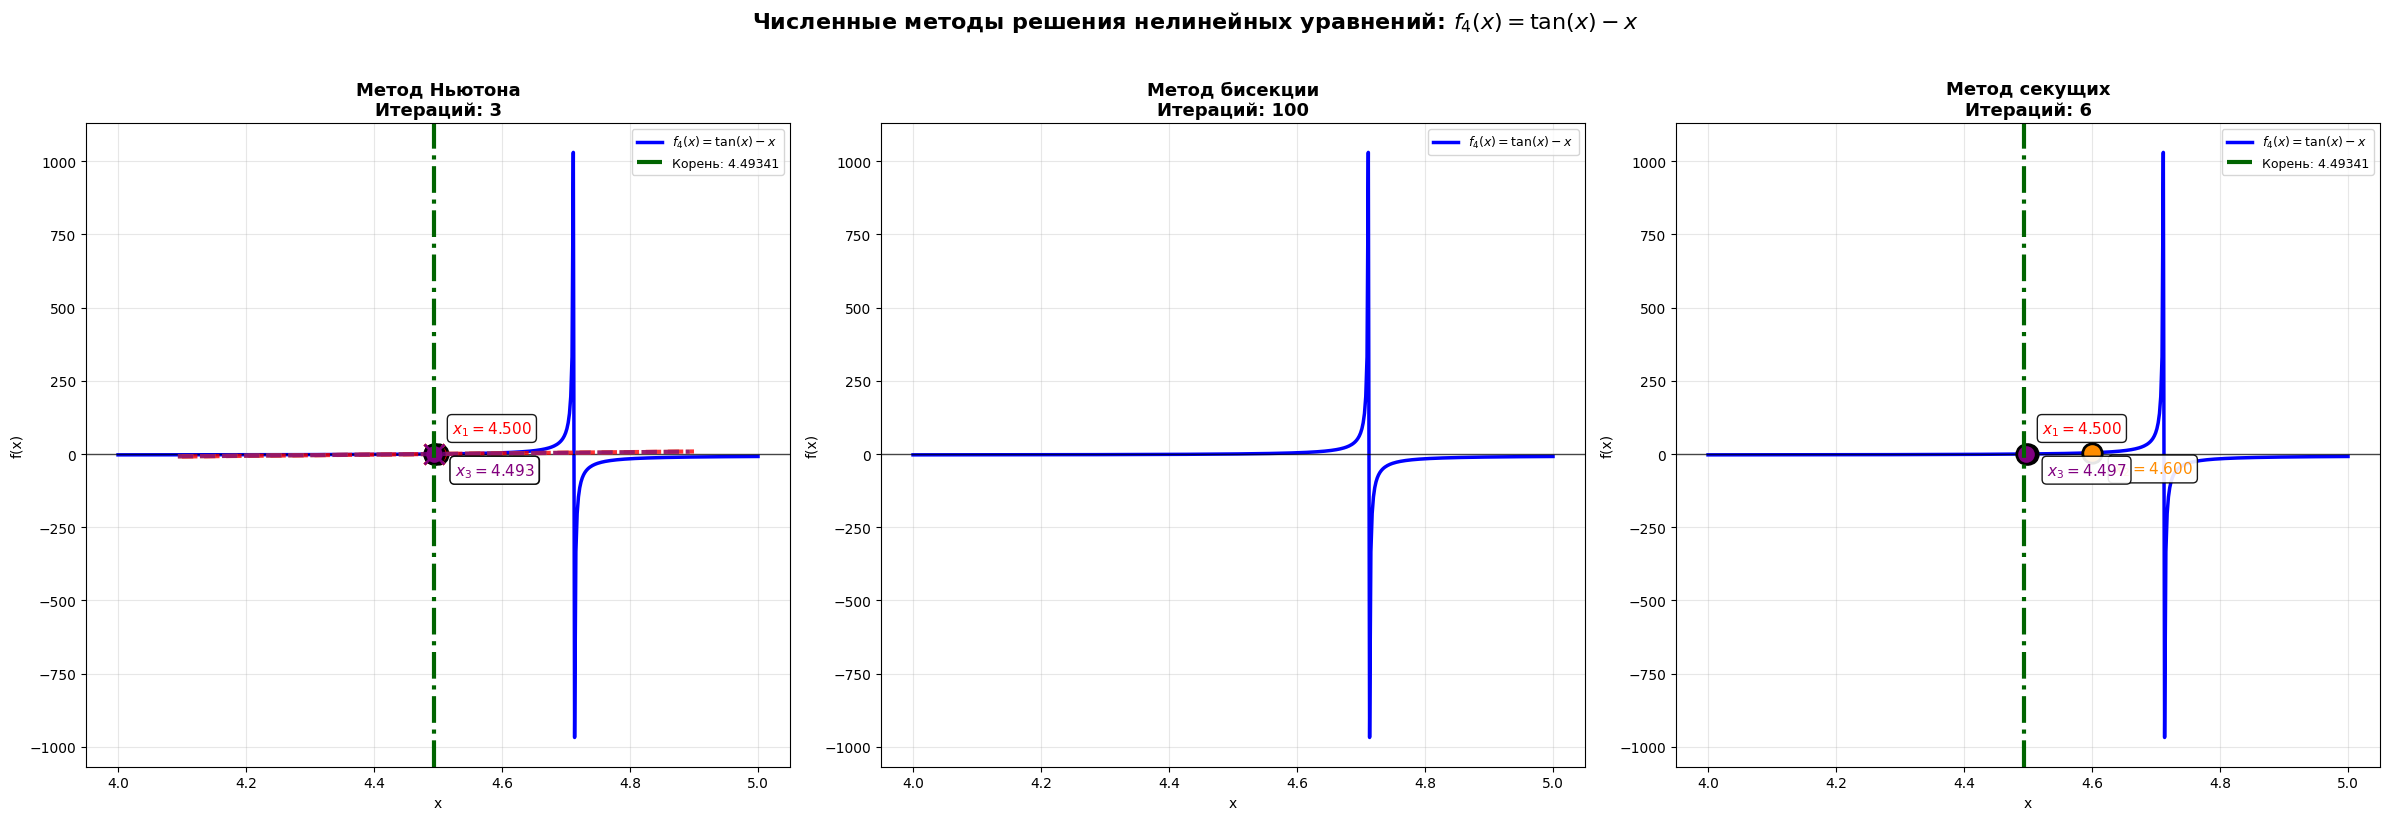

f4(x): Ньютон=3, Бисекция=100, Секущих=6

ИТОГОВАЯ СВОДКА ПО ИТЕРАЦИЯМ
        Метод Ньютона  Метод бисекции  Метод секущих
f_1(x)              3              21              5
f_2(x)              6              21            100
f_3(x)            100               6            100
f_4(x)              3             100              6


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize
import pandas as pd

# Список функций
functions = [
    {
        'name': '$f_1(x) = x^3 - x - 2$',
        'func': lambda x: x**3 - x - 2,
        'deriv': lambda x: 3*x**2 - 1,
        'x0': 1.5,
        'x_range': np.linspace(0.5, 2.5, 500)
    },
    {
        'name': '$f_2(x) = x \\cdot \\sin(\\frac{1}{x})$',
        'func': lambda x: np.where(x != 0, x * np.sin(1/x), 0),
        'deriv': lambda x: np.where(x != 0, np.sin(1/x) - np.cos(1/x)/x, 0),
        'x0': 0.8,
        'x_range': np.linspace(0.3, 1.5, 500)
    },
    {
        'name': '$f_3(x) = (x - 1)^3$',
        'func': lambda x: (x - 1)**3,
        'deriv': lambda x: 3*(x - 1)**2,
        'x0': 1.1,
        'x_range': np.linspace(0.5, 1.7, 500)
    },
    {
        'name': '$f_4(x) = \\tan(x) - x$',
        'func': lambda x: np.tan(x) - x,
        'deriv': lambda x: 1/np.cos(x)**2 - 1,
        'x0': 4.5,
        'x_range': np.linspace(4.0, 5.0, 500)
    }
]

def newton_method(f, df, x0, tol=1e-6, maxiter=100):
    history = [x0]
    for i in range(maxiter):
        fx, dfx = f(x0), df(x0)
        if abs(dfx) < 1e-10:
            break
        x_new = x0 - fx / dfx
        history.append(x_new)
        if abs(x_new - x0) < tol:
            return history, i + 1
        x0 = x_new
    return history, maxiter

def bisection_method(f, a, b, tol=1e-6, maxiter=100):
    if f(a) * f(b) >= 0:
        return [], maxiter
    history = []
    for i in range(maxiter):
        c = (a + b) / 2
        history.append(c)
        if abs(f(c)) < tol or (b - a) / 2 < tol:
            return history, i + 1
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return history, maxiter

def secant_method(f, x0, x1, tol=1e-6, maxiter=100):
    history = [x0, x1]
    for i in range(maxiter):
        fx0, fx1 = f(history[-2]), f(history[-1])
        if abs(fx1 - fx0) < 1e-10:
            break
        try:
            x_new = history[-1] - fx1 * (history[-1] - history[-2]) / (fx1 - fx0)
            history.append(x_new)
            if abs(x_new - history[-2]) < tol:
                return history, i + 2
        except:
            break
    return history, maxiter

def plot_enhanced(ax, f, df, x_range, history, method_name, iterations, func_name, is_newton=False):
    colors = ['red', 'darkorange', 'purple']

    # График функции
    ax.plot(x_range, f(x_range), 'b-', linewidth=2.5, label=func_name)
    ax.axhline(0, color='k', linewidth=1.0, alpha=0.7)

    steps_limited = history[:4]

    # Только для первых 3 шагов
    for i in range(min(3, len(steps_limited)-1)):
        x_curr = steps_limited[i]
        y_curr = f(x_curr)

        # Точка на кривой
        ax.plot(x_curr, y_curr, 'o', color=colors[i], markersize=14,
                markeredgewidth=2, markeredgecolor='black')

        # Вертикальная линия до оси X
        ax.plot([x_curr, x_curr], [0, y_curr], ':',
                color=colors[i], linewidth=1.5, alpha=0.7)

        if is_newton:
            # Касательная для Ньютона
            df_curr = df(x_curr)
            x_next = steps_limited[i+1]
            tangent_x = np.linspace(x_curr-0.4, x_curr+0.4, 80)
            tangent_y = y_curr + df_curr * (tangent_x - x_curr)
            ax.plot(tangent_x, tangent_y, '--', color=colors[i],
                   linewidth=3.0, alpha=0.8)
            ax.plot(x_next, 0, 'x', color=colors[i], markersize=14,
                   markeredgewidth=2)

        # Аннотация с правильным позиционированием
        offset_x, offset_y = (10 if i==0 else 15, 15 if i==0 else -15)
        ax.annotate(f'$x_{i+1} = {x_curr:.3f}$', (x_curr, y_curr),
                   xytext=(offset_x, offset_y), textcoords='offset points',
                   fontsize=11, color=colors[i], fontweight='bold',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9))

    # Точный корень SciPy
    try:
        root_scipy = optimize.newton(f, history[0])
        ax.axvline(root_scipy, color='darkgreen', linestyle='-.', linewidth=3,
                  label=f'Корень: {root_scipy:.5f}')
    except:
        pass

    ax.grid(True, alpha=0.3)
    ax.set_title(f'{method_name}\nИтераций: {iterations}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')

def create_dashboard(func_data, func_idx):
    f, df = func_data['func'], func_data['deriv']
    x_range = func_data['x_range']
    x0 = func_data['x0']

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))  # УВЕЛИЧЕННЫЕ ПОЛОТНА!
    fig.suptitle(f'Численные методы решения нелинейных уравнений: {func_data["name"]}',
                fontsize=16, fontweight='bold', y=1.02)

    # Метод Ньютона
    newton_hist, newton_iter = newton_method(f, df, x0)
    plot_enhanced(axes[0], f, df, x_range, newton_hist, 'Метод Ньютона',
                 newton_iter, func_data['name'], is_newton=True)

    # Метод бисекции
    a, b = min(x_range), max(x_range)
    bisection_hist, bisection_iter = bisection_method(f, a, b)
    plot_enhanced(axes[1], f, None, x_range, bisection_hist, 'Метод бисекции',
                 bisection_iter, func_data['name'], is_newton=False)

    # Метод секущих
    secant_hist, secant_iter = secant_method(f, x0, x0+0.1)
    plot_enhanced(axes[2], f, None, x_range, secant_hist, 'Метод секущих',
                 secant_iter, func_data['name'], is_newton=False)

    plt.tight_layout()
    plt.show()

    return newton_iter, bisection_iter, secant_iter

# ЧИСТЫЙ ВЫВОД БЕЗ WARNING
print("Анализ сходимости численных методов\n")
summary_data = []

for i, func_data in enumerate(functions):
    iters = create_dashboard(func_data, i)
    print(f"f{i+1}(x): Ньютон={iters[0]}, Бисекция={iters[1]}, Секущих={iters[2]}")
    summary_data.append(iters)

print("\n" + "="*50)
print("ИТОГОВАЯ СВОДКА ПО ИТЕРАЦИЯМ")
print("="*50)
df = pd.DataFrame(summary_data,
                  columns=['Метод Ньютона', 'Метод бисекции', 'Метод секущих'],
                  index=[f'f_{i+1}(x)' for i in range(4)])
print(df.astype(int))